# Configuration

In [85]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import httpx
import csv
import geopandas as gpd
from shapely.geometry import Point

DATA_DIR = Path("data")
OUTPUT_DIR = Path("outputs")
CSV_PATH = DATA_DIR / "montreal_climate_2015_2025.csv"
ENRICHED_CSV_PATH = DATA_DIR / "montreal_climate_2015_2025_enriched.csv"

def get_climate_csv_path():
    return ENRICHED_CSV_PATH if ENRICHED_CSV_PATH.exists() else CSV_PATH


# Téléchargement des données

In [86]:
if not CSV_PATH.exists():
    BASE_URL = "https://api.weather.gc.ca/collections/climate-daily/items"
    BBOX = "-73.8,45.4,-73.4,45.7"
    DATETIME = "2015-01-01T00:00:00Z/2025-12-31T23:59:59Z"
    FIELDS = ["LOCAL_DATE", "STATION_NAME", "CLIMATE_IDENTIFIER", "MEAN_TEMPERATURE", "MIN_TEMPERATURE", "MAX_TEMPERATURE",
              "TOTAL_PRECIPITATION", "TOTAL_RAIN", "TOTAL_SNOW", "SNOW_ON_GROUND", "SPEED_MAX_GUST", "HEATING_DEGREE_DAYS",
              "COOLING_DEGREE_DAYS", "MIN_REL_HUMIDITY", "MAX_REL_HUMIDITY"]
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    all_features = []
    offset = 0

    with httpx.Client() as client:
        while True:
            r = client.get(BASE_URL, params={"f": "json", "bbox": BBOX, "datetime": DATETIME, "limit": 5000, "offset": offset}, timeout=30.0)
            r.raise_for_status()
            data = r.json()
            features = data.get("features") or []
            if not features:
                break
            all_features.extend(features)
            offset += 5000
            if len(features) < 5000:
                break

    rows = []
    for f in all_features:
        props = f.get("properties") or {}
        rows.append({k: ("" if props.get(k) is None else props.get(k)) for k in FIELDS})

    with open(CSV_PATH, "w", newline="", encoding="utf-8") as f:
        w = csv.DictWriter(f, fieldnames=FIELDS)
        w.writeheader()
        w.writerows(rows)

    print(f"Téléchargé {len(rows)} enregistrements → {CSV_PATH}")
else:
    print(f"Fichier déjà présent : {CSV_PATH}")


Fichier déjà présent : data/montreal_climate_2015_2025.csv


In [87]:
if CSV_PATH.exists():
    NUMERIC_COLS = [
        "MEAN_TEMPERATURE", "MIN_TEMPERATURE", "MAX_TEMPERATURE",
        "TOTAL_PRECIPITATION", "TOTAL_RAIN", "TOTAL_SNOW", "SNOW_ON_GROUND",
        "SPEED_MAX_GUST", "HEATING_DEGREE_DAYS", "COOLING_DEGREE_DAYS",
        "MIN_REL_HUMIDITY", "MAX_REL_HUMIDITY",
    ]

    df = pd.read_csv(CSV_PATH, encoding="utf-8")
    df["LOCAL_DATE"] = pd.to_datetime(df["LOCAL_DATE"].astype(str).str.slice(0, 10))

    for col in NUMERIC_COLS:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    df["_has_snow"] = df["TOTAL_SNOW"].notna()
    df["_n_filled"] = df[NUMERIC_COLS].notna().sum(axis=1)

    rows = []
    for date, grp in df.groupby("LOCAL_DATE"):
        with_snow = grp[grp["_has_snow"]]
        if len(with_snow) > 0:
            best = with_snow.loc[with_snow["_n_filled"].idxmax()]
        else:
            best = grp.loc[grp["_n_filled"].idxmax()]
        row = best.drop(labels=["_has_snow", "_n_filled"], errors="ignore").to_dict()

        if "TOTAL_SNOW" in grp.columns and grp["TOTAL_SNOW"].notna().any():
            row["TOTAL_SNOW"] = grp["TOTAL_SNOW"].max()
        rows.append(row)

    out = pd.DataFrame(rows)
    cols = [c for c in df.columns if c not in ("_has_snow", "_n_filled")]
    out = out[[c for c in cols if c in out.columns]]

    ENRICHED_CSV_PATH.parent.mkdir(parents=True, exist_ok=True)
    out.to_csv(ENRICHED_CSV_PATH, index=False)

    n_snow = out["TOTAL_SNOW"].notna().sum()
    print(f"Enrichi : {len(out)} jours -> {ENRICHED_CSV_PATH}")
    print(f"TOTAL_SNOW non-null : {n_snow} ({100 * n_snow / len(out):.1f}%)")
else:
    print("Exécutez d'abord la cellule de téléchargement ci-dessus.")


Enrichi : 4018 jours -> data/montreal_climate_2015_2025_enriched.csv
TOTAL_SNOW non-null : 4017 (100.0%)


# Nettoyage

In [88]:
csv_path = get_climate_csv_path()
df = pd.read_csv(csv_path, encoding="utf-8")
df["LOCAL_DATE"] = pd.to_datetime(df["LOCAL_DATE"].astype(str).str.slice(0, 10))

numeric_cols = [
    "MEAN_TEMPERATURE", "MIN_TEMPERATURE", "MAX_TEMPERATURE",
    "TOTAL_PRECIPITATION", "TOTAL_RAIN", "TOTAL_SNOW",
    "SNOW_ON_GROUND", "SPEED_MAX_GUST", "HEATING_DEGREE_DAYS",
    "MIN_REL_HUMIDITY", "MAX_REL_HUMIDITY",
]
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

ROLLING_PRECIP_3D = "PRECIP_SUM_3D"
ROLLING_PRECIP_5D = "PRECIP_SUM_5D"
ROLLING_SNOW_3D = "SNOW_SUM_3D"
ROLLING_SNOW_5D = "SNOW_SUM_5D"
ROLLING_MEAN_TEMP_3D = "MEAN_TEMP_3D"
ROLLING_MIN_TEMP_3D = "MIN_TEMP_3D"

def add_rolling_features(
    df: pd.DataFrame,
    date_col: str = "LOCAL_DATE",
    precip_col: str = "TOTAL_PRECIPITATION",
    snow_col: str = "TOTAL_SNOW",
    mean_temp_col: str = "MEAN_TEMPERATURE",
    min_temp_col: str = "MIN_TEMPERATURE",
    windows: tuple[int, ...] = (3, 5),
) -> pd.DataFrame:
    out = df.copy()
    if date_col not in out.columns:
        return out
    out = out.sort_values(date_col).reset_index(drop=True)

    if precip_col in out.columns:
        p = pd.to_numeric(out[precip_col], errors="coerce").fillna(0)
        if 3 in windows:
            out[ROLLING_PRECIP_3D] = p.rolling(window=3, min_periods=1).sum()
        if 5 in windows:
            out[ROLLING_PRECIP_5D] = p.rolling(window=5, min_periods=1).sum()

    if snow_col in out.columns:
        s = pd.to_numeric(out[snow_col], errors="coerce").fillna(0)
        out[ROLLING_SNOW_3D] = s.rolling(window=3, min_periods=1).sum()
        out[ROLLING_SNOW_5D] = s.rolling(window=5, min_periods=1).sum()

    if mean_temp_col in out.columns:
        t = pd.to_numeric(out[mean_temp_col], errors="coerce")
        out[ROLLING_MEAN_TEMP_3D] = t.rolling(window=3, min_periods=1).mean()
    if min_temp_col in out.columns:
        tmin = pd.to_numeric(out[min_temp_col], errors="coerce")
        out[ROLLING_MIN_TEMP_3D] = tmin.rolling(window=3, min_periods=1).min()

    return out

df = add_rolling_features(df)
print(f"Source : {csv_path.name}, {len(df)} lignes, TOTAL_SNOW non-null : {df['TOTAL_SNOW'].notna().sum()}")
df.head(10)


Source : montreal_climate_2015_2025_enriched.csv, 4018 lignes, TOTAL_SNOW non-null : 4017


,LOCAL_DATE,STATION_NAME,CLIMATE_IDENTIFIER,MEAN_TEMPERATURE,MIN_TEMPERATURE,MAX_TEMPERATURE,TOTAL_PRECIPITATION,TOTAL_RAIN,TOTAL_SNOW,SNOW_ON_GROUND,...,HEATING_DEGREE_DAYS,COOLING_DEGREE_DAYS,MIN_REL_HUMIDITY,MAX_REL_HUMIDITY,PRECIP_SUM_3D,PRECIP_SUM_5D,SNOW_SUM_3D,SNOW_SUM_5D,MEAN_TEMP_3D,MIN_TEMP_3D
0,2015-01-01,MONTREAL INTL A,7025251,-5.3,-7.6,-3.0,1.8,0.0,2.4,0.0,...,23.3,0.0,NaN,NaN,1.8,1.8,2.4,2.4,-5.300000,-7.6
1,2015-01-02,MONTREAL INTL A,7025251,-8.8,-14.2,-3.4,0.0,0.0,0.0,1.0,...,26.8,0.0,NaN,NaN,1.8,1.8,2.4,2.4,-7.050000,-14.2
2,2015-01-03,MONTREAL INTL A,7025251,-13.1,-17.7,-8.5,17.0,0.0,17.0,1.0,...,31.1,0.0,NaN,NaN,18.8,18.8,19.4,19.4,-9.066667,-17.7
3,2015-01-04,MONTREAL INTL A,7025251,-2.8,-8.6,3.0,27.2,26.8,1.4,8.0,...,20.8,0.0,NaN,NaN,44.2,46.0,18.4,20.8,-8.233333,-17.7
4,2015-01-05,MONTREAL INTL A,7025251,-11.6,-17.9,-5.3,0.0,0.0,0.0,6.0,...,29.6,0.0,NaN,NaN,44.2,46.0,18.4,20.8,-9.166667,-17.9
5,2015-01-06,MONTREAL INTL A,7025251,-13.9,-19.1,-8.6,2.2,0.0,5.0,6.0,...,31.9,0.0,NaN,NaN,29.4,46.4,6.4,23.4,-9.433333,-19.1
6,2015-01-07,MONTREAL INTL A,7025251,-17.7,-26.4,-9.0,3.8,0.0,4.0,8.0,...,35.7,0.0,NaN,NaN,6.0,50.2,9.0,27.4,-14.400000,-26.4
7,2015-01-08,MONTREAL INTL A,7025251,-17.5,-27.5,-7.4,2.2,0.0,7.6,10.0,...,35.5,0.0,NaN,NaN,8.2,35.4,16.6,18.0,-16.366667,-27.5
8,2015-01-09,MONTREAL INTL A,7025251,-10.4,-14.6,-6.1,2.6,0.0,4.6,12.0,...,28.4,0.0,NaN,NaN,8.6,10.8,16.2,21.2,-15.200000,-27.5
9,2015-01-10,MONTREAL INTL A,7025251,-11.2,-13.4,-9.0,0.4,0.0,0.4,7.0,...,29.2,0.0,NaN,NaN,5.2,11.2,12.6,21.6,-13.033333,-27.5


In [89]:
rolling_cols = [c for c in ["PRECIP_SUM_3D", "PRECIP_SUM_5D", "SNOW_SUM_3D", "SNOW_SUM_5D", "MEAN_TEMP_3D", "MIN_TEMP_3D"] if c in df.columns]
if rolling_cols and "TOTAL_SNOW" in df.columns:
    corr_rolling = df[rolling_cols + ["TOTAL_SNOW"]].corr()["TOTAL_SNOW"].drop("TOTAL_SNOW", errors="ignore")
    corr_rolling = corr_rolling.reindex(corr_rolling.abs().sort_values(ascending=False).index)
    print("Corrélations avec TOTAL_SNOW (variables glissantes) :")
    display(corr_rolling)
else:
    print("Variables glissantes :", rolling_cols)


Corrélations avec TOTAL_SNOW (variables glissantes) :


SNOW_SUM_3D      0.646356
SNOW_SUM_5D      0.550237
MEAN_TEMP_3D    -0.311231
MIN_TEMP_3D     -0.301862
PRECIP_SUM_3D    0.153797
PRECIP_SUM_5D    0.115040
Name: TOTAL_SNOW, dtype: float64

# Choix de la station

In [90]:
if "STATION_NAME" in df.columns and len(df) != df["LOCAL_DATE"].nunique():
    station_counts = df.groupby("STATION_NAME").size().sort_values(ascending=False)
    print("Nombre de jours par station :")
    display(station_counts)
    main_station = station_counts.index[0]
    df_station = df[df["STATION_NAME"] == main_station].copy()
    print(f"\nSérie retenue : {main_station} ({len(df_station)} jours)")
else:
    df_station = df.copy()
    print(f"Série retenue : une ligne par date ({len(df_station)} jours)")


Série retenue : une ligne par date (4018 jours)


# Statistiques descriptives

,CLIMATE_IDENTIFIER,MEAN_TEMPERATURE,MIN_TEMPERATURE,MAX_TEMPERATURE,TOTAL_PRECIPITATION,TOTAL_RAIN,TOTAL_SNOW,SNOW_ON_GROUND,SPEED_MAX_GUST,HEATING_DEGREE_DAYS,COOLING_DEGREE_DAYS,MIN_REL_HUMIDITY,MAX_REL_HUMIDITY,PRECIP_SUM_3D,PRECIP_SUM_5D,SNOW_SUM_3D,SNOW_SUM_5D,MEAN_TEMP_3D,MIN_TEMP_3D
count,4.018000e+03,3972.000000,4015.000000,4016.000000,4013.000000,4012.000000,4017.000000,1782.000000,2921.000000,3972.000000,3972.000000,2561.000000,2561.000000,4018.000000,4018.000000,4018.000000,4018.000000,4017.000000,4018.000000
mean,7.025324e+06,7.836581,3.270535,12.447883,2.973038,2.388435,0.743415,6.700898,43.320781,11.185247,1.021828,52.044123,85.911363,8.905923,14.837183,2.227601,3.711971,7.882806,0.848034
std,7.234573e+02,11.769208,11.454052,12.329136,7.154795,6.785111,2.803424,9.530635,16.135497,10.537820,2.145705,15.292615,9.820874,12.720446,16.123584,5.640652,7.965292,11.528414,11.773816
min,7.020392e+06,-23.700000,-29.500000,-20.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,11.000000,38.000000,0.000000,0.000000,0.000000,0.000000,-22.200000,-29.500000
25%,7.025251e+06,-1.400000,-4.800000,2.200000,0.000000,0.000000,0.000000,0.000000,35.000000,0.000000,0.000000,41.000000,81.000000,0.400000,3.200000,0.000000,0.000000,-1.300000,-8.000000
50%,7.025251e+06,8.500000,4.000000,13.100000,0.000000,0.000000,0.000000,2.000000,43.000000,9.500000,0.000000,52.000000,88.000000,4.200000,10.100000,0.000000,0.000000,8.700000,1.700000
75%,7.025251e+06,18.300000,13.100000,23.700000,2.400000,1.000000,0.000000,10.000000,52.000000,19.400000,0.300000,62.000000,93.000000,12.400000,21.000000,0.800000,3.400000,18.466667,11.300000
max,7.026612e+06,30.100000,24.000000,36.600000,154.000000,154.000000,39.200000,99.000000,117.000000,41.700000,12.100000,98.000000,100.000000,159.000000,163.400000,51.400000,74.600000,28.533333,22.400000


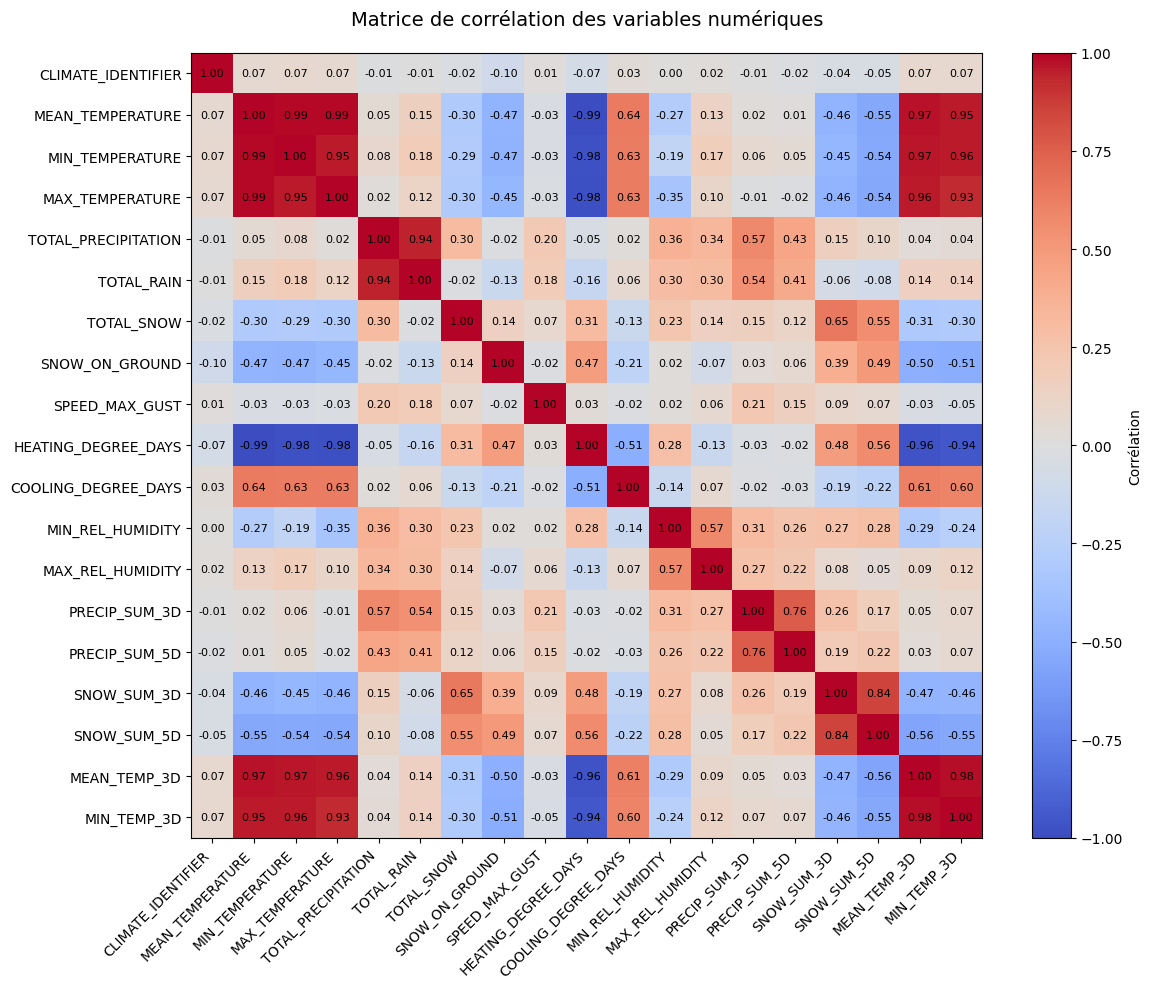

Corrélations avec TOTAL_SNOW (ordre décroissant) :


SNOW_SUM_3D            0.646356
SNOW_SUM_5D            0.550237
MEAN_TEMP_3D          -0.311231
HEATING_DEGREE_DAYS    0.309446
MAX_TEMPERATURE       -0.304395
TOTAL_PRECIPITATION    0.302298
MIN_TEMP_3D           -0.301862
MEAN_TEMPERATURE      -0.300198
MIN_TEMPERATURE       -0.287238
MIN_REL_HUMIDITY       0.233352
Name: TOTAL_SNOW, dtype: float64

In [91]:
numeric = df_station.select_dtypes(include=["number"])
display(numeric.describe())

corr = numeric.corr()

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr.values, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        text = ax.text(j, i, f'{corr.iloc[i, j]:.2f}',
                      ha="center", va="center", color="black", fontsize=8)

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticklabels(corr.columns)

ax.set_title("Matrice de corrélation des variables numériques", fontsize=14, pad=20)
plt.colorbar(im, ax=ax, label='Corrélation')
plt.tight_layout()
plt.show()

if "TOTAL_SNOW" in corr.columns:
    snow_corr = corr["TOTAL_SNOW"].drop("TOTAL_SNOW", errors="ignore")
    snow_corr = snow_corr.iloc[snow_corr.abs().argsort()[::-1]].head(10)
    print("Corrélations avec TOTAL_SNOW (ordre décroissant) :")
    display(snow_corr)


# Analyse des événements de neige

Jours couverts par les événements listés : 14


,LOCAL_DATE,TOTAL_SNOW,MEAN_TEMPERATURE,event_name
803,2017-03-14,31.6,-8.5,Crise Autoroute 13 mars 2017 (35-50 cm)
804,2017-03-15,7.8,-6.2,Crise Autoroute 13 mars 2017 (35-50 cm)
1504,2019-02-13,20.6,-3.6,"Tempête fév 2019 (~40 cm, écoles fermées)"
1863,2020-02-07,27.4,-8.8,"Tempête 7 fév 2020 (~40 cm, déneigement, caram..."
2573,2022-01-17,16.4,-10.1,"Tempête 17 jan 2022 (25-35 cm, écoles, courrier)"
2912,2022-12-22,9.2,-5.8,"Tempête fin déc 2022 (~40 cm, aéroport)"
2913,2022-12-23,14.4,-0.9,"Tempête fin déc 2022 (~40 cm, aéroport)"
2914,2022-12-24,0.8,-8.7,"Tempête fin déc 2022 (~40 cm, aéroport)"
3380,2024-04-03,6.7,5.3,Neige lourde avr 2024 (25-35 cm)
3381,2024-04-04,20.0,-0.1,Neige lourde avr 2024 (25-35 cm)



Statistiques descriptives: uniquement les 14 jours couverts (épisodes SNOW_EVENTS) :


,count,mean,std,min,5%,10%,25%,50%,75%,90%,95%,max
TOTAL_SNOW,14.0,16.235714,12.598633,0.0,0.520,1.04,6.975,15.40,25.700,33.28,34.980,36.8
MEAN_TEMPERATURE,14.0,-6.264286,4.858871,-11.4,-11.335,-10.94,-9.625,-8.10,-4.150,-0.34,1.790,5.3
MIN_TEMPERATURE,14.0,-9.792857,4.826444,-16.9,-16.055,-15.33,-12.400,-9.70,-8.375,-3.23,-0.805,0.3
MAX_TEMPERATURE,14.0,-2.678571,5.893827,-9.1,-8.450,-7.98,-7.425,-3.75,-0.275,5.99,8.770,10.2
MAX_REL_HUMIDITY,12.0,88.916667,6.402533,73.0,77.950,82.20,86.250,92.00,93.000,93.90,94.000,94.0


Quartiles et écart interquartile (IQR = Q3 − Q1), jours couverts :


,TOTAL_SNOW,MEAN_TEMPERATURE,MIN_TEMPERATURE,MAX_TEMPERATURE,MAX_REL_HUMIDITY
Q1,6.975,-9.625,-12.400,-7.425,86.25
Q3,25.700,-4.150,-8.375,-0.275,93.00
IQR,18.725,5.475,4.025,7.150,6.75


/tmp/ipykernel_45114/1434536917.py:59: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(series, vert=True, labels=[col])
/tmp/ipykernel_45114/1434536917.py:59: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(series, vert=True, labels=[col])
/tmp/ipykernel_45114/1434536917.py:59: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(series, vert=True, labels=[col])
/tmp/ipykernel_45114/1434536917.py:59: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(series, vert=True

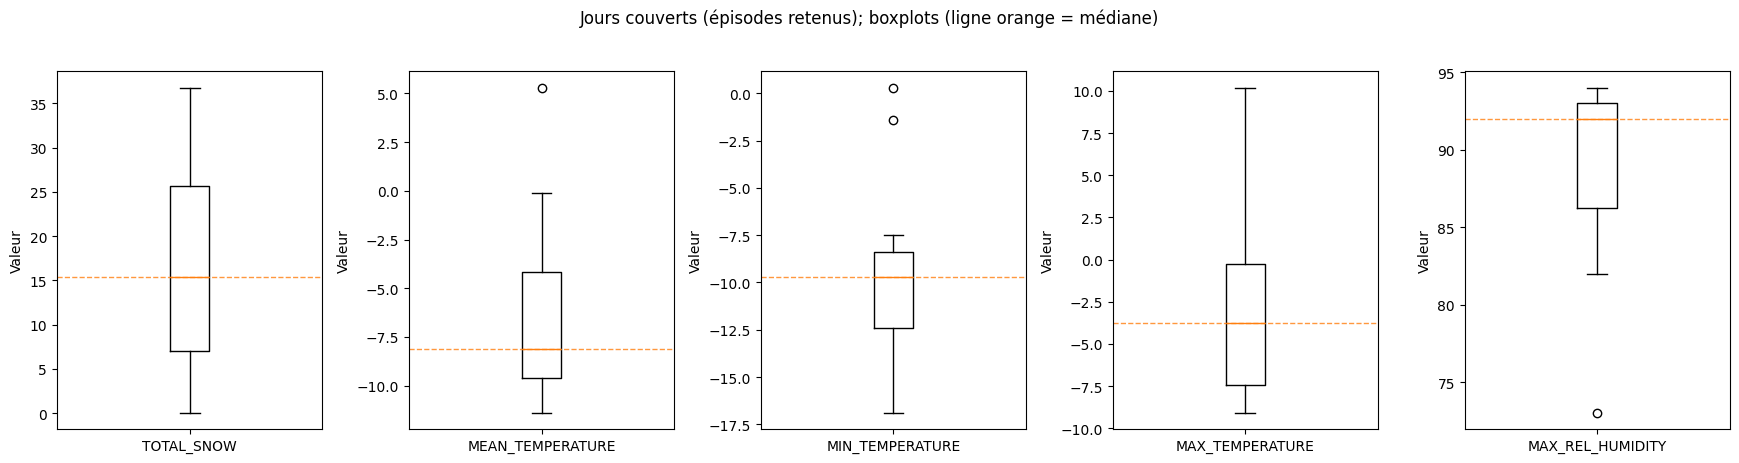

In [92]:
SNOW_EVENTS = [
    ("2025-02-13", "2025-02-16", "Blizzard fév 2025 (72,4 cm, 4 j)", 72.4),
    ("2024-04-03", "2024-04-04", "Neige lourde avr 2024 (25-35 cm)", 30),
    ("2022-12-22", "2022-12-24", "Tempête fin déc 2022 (~40 cm, aéroport)", 40),
    ("2019-02-13", "2019-02-13", "Tempête fév 2019 (~40 cm, écoles fermées)", 40),
    ("2017-03-14", "2017-03-15", "Crise Autoroute 13 mars 2017 (35-50 cm)", 42.5),
    ("2022-01-17", "2022-01-17", "Tempête 17 jan 2022 (25-35 cm, écoles, courrier)", 30),
    ("2020-02-07", "2020-02-07", "Tempête 7 fév 2020 (~40 cm, déneigement, carambolages)", 40),
]

df_station["event_name"] = ""
for start, end, name, *_ in SNOW_EVENTS:
    mask = (df_station["LOCAL_DATE"] >= pd.to_datetime(start)) & (df_station["LOCAL_DATE"] <= pd.to_datetime(end))
    df_station.loc[mask, "event_name"] = name

event_days = df_station[df_station["event_name"] != ""].copy()
print(f"Jours couverts par les événements listés : {len(event_days)}")
display(event_days[["LOCAL_DATE", "TOTAL_SNOW", "MEAN_TEMPERATURE", "event_name"]])

stat_cols = [
    c
    for c in (
        "TOTAL_SNOW",
        "MEAN_TEMPERATURE",
        "MIN_TEMPERATURE",
        "MAX_TEMPERATURE",
        "MAX_REL_HUMIDITY",
    )
    if c in event_days.columns
]
event_num = event_days[stat_cols].apply(pd.to_numeric, errors="coerce")

print(
    f"\nStatistiques descriptives: uniquement les {len(event_days)} jours couverts (épisodes SNOW_EVENTS) :"
)
display(
    event_num.describe(
        percentiles=[0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95]
    ).T
)

iqr_tbl = pd.DataFrame(
    {
        "Q1": event_num.quantile(0.25),
        "Q3": event_num.quantile(0.75),
        "IQR": event_num.quantile(0.75) - event_num.quantile(0.25),
    }
)
print("Quartiles et écart interquartile (IQR = Q3 − Q1), jours couverts :")
display(iqr_tbl.T)

if stat_cols:
    n = len(stat_cols)
    fig, axes = plt.subplots(1, n, figsize=(max(5, 3.5 * n), 4.5))
    if n == 1:
        axes = [axes]
    for ax, col in zip(axes, stat_cols):
        series = event_num[col].dropna()
        ax.boxplot(series, vert=True, labels=[col])
        ax.set_ylabel("Valeur")
        med = series.median()
        ax.axhline(med, color="tab:orange", linestyle="--", linewidth=1, alpha=0.8)
    fig.suptitle(
        "Jours couverts (épisodes retenus); boxplots (ligne orange = médiane)",
        y=1.02,
    )
    plt.tight_layout()
    plt.show()


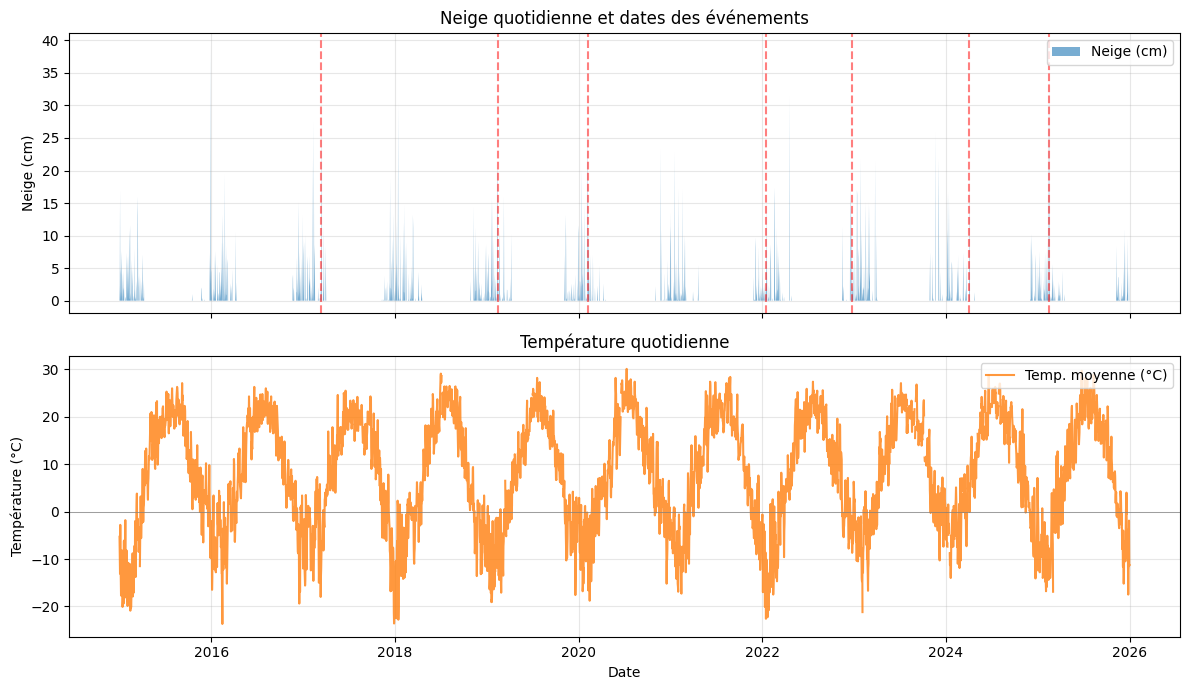

In [93]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
ax1, ax2 = axes
ax1.fill_between(df_station["LOCAL_DATE"], 0, df_station["TOTAL_SNOW"].fillna(0), alpha=0.6, label="Neige (cm)")
for _, row in event_days.drop_duplicates("event_name").iterrows():
    ax1.axvline(row["LOCAL_DATE"], color="red", alpha=0.5, linestyle="--")
ax1.set_ylabel("Neige (cm)")
ax1.set_title("Neige quotidienne et dates des événements")
ax1.legend(loc="upper right")
ax1.grid(True, alpha=0.3)
ax2.plot(df_station["LOCAL_DATE"], df_station["MEAN_TEMPERATURE"], color="tab:orange", alpha=0.8, label="Temp. moyenne (°C)")
ax2.axhline(0, color="gray", linestyle="-", linewidth=0.5)
ax2.set_ylabel("Température (°C)")
ax2.set_xlabel("Date")
ax2.set_title("Température quotidienne")
ax2.legend(loc="upper right")
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


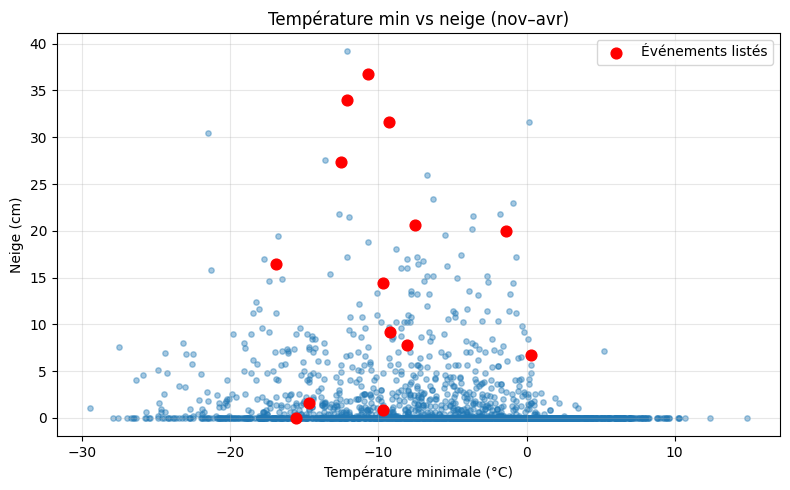

In [94]:
df_station["month"] = df_station["LOCAL_DATE"].dt.month
winter = df_station[df_station["month"].isin([11, 12, 1, 2, 3, 4])]
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(winter["MIN_TEMPERATURE"], winter["TOTAL_SNOW"], alpha=0.4, s=15)
event_w = winter[winter["event_name"] != ""]
if not event_w.empty:
    ax.scatter(event_w["MIN_TEMPERATURE"], event_w["TOTAL_SNOW"], color="red", s=60, label="Événements listés", zorder=5)
ax.set_xlabel("Température minimale (°C)")
ax.set_ylabel("Neige (cm)")
ax.set_title("Température min vs neige (nov–avr)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# Risque de neige par règles de décision (sans modèle)

Les épisodes de chutes de neige forts analysés plus haut et les seuils de l'INSPQ servent à **interpréter** les tempêtes ; la **formule** qui transforme les indicateurs météo en probabilité est celle de `server/app/risk_assessors/snow.py`. La **probabilité affichée** combine ensuite ce risque métier avec le **score territorial** (IRIU), selon `server/app/utils/scoring.py` (`combined_probability`).

## Entrées (par jour)

- **Neige du jour** `snow` (cm), prévision `snowfall_sum` (Open-Meteo).
- **Température** : moyenne quotidienne.
- **Humidité** : maximum relatif (0-100 %).
- **Voisinage** : neige en **J−1**, **J−2** (cumuls) et **J+1** (lendemain, incrément « prévision »).

**Cumuls vers l'arrière**

- `accum_2d_back = neige(J-1) + neige(J)`
- `accum_3d_back = neige(J-2) + neige(J-1) + neige(J)`

## Juin à septembre

Probabilité **0** (mois 6 à 9).

## Risque brut (`raw_prediction_value`)

Chaque terme est une contribution entre **0** et **1** ; la somme est **bornée à 1**.

1. **Base 20 %** (`risk_base = 0,20`) si, hors été, **au moins une** des conditions suivantes est vraie :
   - `snow > 10` cm le jour considéré, **ou**
   - `accum_2d_back ≥ 15` cm, **ou**
   - `accum_3d_back ≥ 20` cm.

2. **`apply_inc`** active les incréments « météo ». La condition reprend la même logique que la base, avec **`snow ≥ 10`** (seuil fermé) pour le jour courant, ou les mêmes seuils sur les cumuls 2 j / 3 j.

3. Si `apply_inc` :
   - **Température** : **+0,10** si −10 °C ≤ T ≤ 0 °C.
   - **Humidité** : **+ min(0,08 ; humidité × 0,0008)**.
   - **Lendemain** : **+ min(0,10 ; neige(J+1) × 0,005)** uniquement si la neige **du jour** ≥ **8 cm** (`MIN_SNOW_CM_FOR_NEXT_DAY_INCREMENT`).
   - **Bandes selon la neige du jour (cm)** - libellés quartiles dans le code :
     - ≤ 8,2 → +0 ;
     - \> 8,2 et ≤ 12,8 → +0,05 ;
     - \> 12,8 et ≤ 20,5 → +0,10 ;
     - \> 20,5 → +0,15.

4. Si **`apply_inc`** est faux et **neige du jour > 0** : **+ min(0,10 ; snow × 0,02)** (petite neige).

5. Somme **plafonnée à 1**. Si **neige du jour = 0**, le risque brut est **0**, y compris lorsque les cumuls sur les jours voisins sont élevés.

## Probabilité combinée (`prediction_value`)

Le risque brut est mélangé au **score de risque** de l'**aire de diffusion** (0–100, GeoJSON) :

`(1 − W) × risque_brut + W × (score_risque / 100)` avec **`W = 0,25`** (`W_IRIU` dans `scoring.py`).

Si le risque brut est **0** après arrondi à **4 décimales**, la probabilité combinée est **0**. Sans identifiant de zone (`adidu` absent), le score territorial est pris à **0** : l'affichage correspond alors à **`0,75 × risque_brut`** lorsque ce dernier est strictement positif.

La cellule de code suivante applique ces règles à l'historique (`df`) ; une colonne illustre le cas où le **score territorial vaut 0**.


Risque de neige par règles de décision (aperçu) :


,LOCAL_DATE,TOTAL_SNOW,MEAN_TEMPERATURE,RISK_BASE,INC_TEMP,INC_HUMIDITY,INC_FORECAST_SNOW,INC_QUARTILE,SNOW_RISK_RULES,PRED_COMBINED_SCORE0
4003,2025-12-17,0.0,0.4,0.0,0.0,0.0,0.0,0.0,0.000,0.000
4004,2025-12-18,0.0,-0.6,0.0,0.0,0.0,0.0,0.0,0.000,0.000
4005,2025-12-19,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.000,0.000
4006,2025-12-20,0.0,-3.6,0.0,0.0,0.0,0.0,0.0,0.000,0.000
4007,2025-12-21,0.8,-3.7,0.0,0.0,0.0,0.0,0.0,0.016,0.012
4008,2025-12-22,1.4,-9.8,0.0,0.0,0.0,0.0,0.0,0.028,0.021
4009,2025-12-23,9.6,-7.4,0.0,0.0,0.0,0.0,0.0,0.100,0.075
4010,2025-12-24,1.6,-5.5,0.0,0.0,0.0,0.0,0.0,0.032,0.024
4011,2025-12-25,5.0,-10.7,0.0,0.0,0.0,0.0,0.0,0.100,0.075
4012,2025-12-26,0.0,-17.5,0.0,0.0,0.0,0.0,0.0,0.000,0.000



Jours où SNOW_RISK_RULES >= 20% : 134

Statistiques descriptives: risque par règles sur les 14 jours couverts (épisodes SNOW_EVENTS) :


,count,mean,std,min,10%,25%,50%,75%,90%,max
TOTAL_SNOW,14.0,16.235714,12.598633,0.0,1.040,6.97500,15.400000,25.70000,33.28000,36.80000
RISK_BASE,14.0,0.171429,0.072627,0.0,0.060,0.20000,0.200000,0.20000,0.20000,0.20000
INC_TEMP,14.0,0.064286,0.049725,0.0,0.000,0.00000,0.100000,0.10000,0.10000,0.10000
INC_HUMIDITY,14.0,0.056000,0.026477,0.0,0.012,0.04460,0.068400,0.07360,0.07440,0.07520
INC_FORECAST_SNOW,14.0,0.004964,0.010485,0.0,0.000,0.00000,0.000000,0.00475,0.01055,0.03900
INC_QUARTILE,14.0,0.075000,0.070027,0.0,0.000,0.00000,0.100000,0.15000,0.15000,0.15000
SNOW_RISK_RULES,14.0,0.367507,0.184026,0.0,0.100,0.28540,0.429650,0.52320,0.52888,0.53060
PRED_COMBINED_SCORE0,14.0,0.275630,0.138019,0.0,0.075,0.21405,0.322238,0.39240,0.39666,0.39795


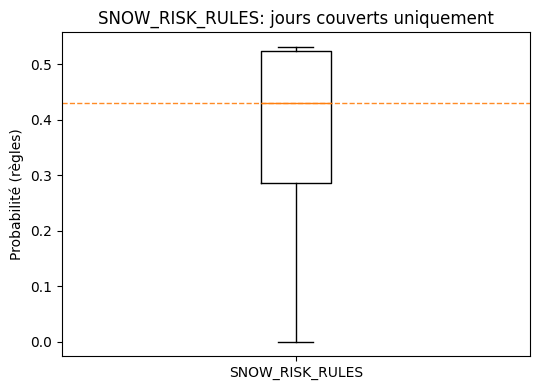

In [95]:
import numpy as np

MIN_SNOW_CM_FOR_NEXT_DAY_INCREMENT = 8.0
W_IRIU = 0.25

rule_df = df[["LOCAL_DATE", "TOTAL_SNOW", "MEAN_TEMPERATURE"]].copy()
rule_df["TOTAL_SNOW"] = pd.to_numeric(rule_df["TOTAL_SNOW"], errors="coerce").fillna(0)
rule_df["MEAN_TEMPERATURE"] = pd.to_numeric(rule_df["MEAN_TEMPERATURE"], errors="coerce")
if "MAX_REL_HUMIDITY" in df.columns:
    rule_df["MAX_REL_HUMIDITY"] = pd.to_numeric(df["MAX_REL_HUMIDITY"], errors="coerce").fillna(50)
else:
    rule_df["MAX_REL_HUMIDITY"] = 50

rule_df = rule_df.sort_values("LOCAL_DATE").reset_index(drop=True)
rule_df["SNOW_NEXT_24H"] = rule_df["TOTAL_SNOW"].shift(-1).fillna(0)

month = rule_df["LOCAL_DATE"].dt.month
snow = rule_df["TOTAL_SNOW"].values
temp = rule_df["MEAN_TEMPERATURE"].values
hum = rule_df["MAX_REL_HUMIDITY"].values
snow_next = rule_df["SNOW_NEXT_24H"].values
snow_prev = rule_df["TOTAL_SNOW"].shift(1).fillna(0).values
snow_prev2 = rule_df["TOTAL_SNOW"].shift(2).fillna(0).values

accum_2d_back = snow_prev + snow
accum_3d_back = snow_prev2 + snow_prev + snow

is_summer = month.isin([6, 7, 8, 9]).values

base = np.where(
    is_summer,
    0.0,
    np.where(
        (snow > 10) | (accum_2d_back >= 15.0) | (accum_3d_back >= 20.0),
        0.20,
        0.0,
    ),
)
apply_inc = (~is_summer) & (
    (snow >= 10.0) | (accum_2d_back >= 15.0) | (accum_3d_back >= 20.0)
)

inc_temp = np.where(
    apply_inc & (temp >= -10) & (temp <= 0),
    0.10,
    0.0,
)
inc_hum = np.where(apply_inc, np.minimum(0.08, hum * 0.0008), 0.0)
inc_forecast = np.where(
    apply_inc & (snow >= MIN_SNOW_CM_FOR_NEXT_DAY_INCREMENT),
    np.minimum(0.10, snow_next * 0.005),
    0.0,
)

inc_quartile = np.where(
    ~apply_inc,
    0.0,
    np.where(
        snow <= 8.2,
        0.0,
        np.where(
            snow <= 12.8,
            0.05,
            np.where(snow <= 20.5, 0.10, 0.15),
        ),
    ),
)

small_snow = np.where((~is_summer) & (~apply_inc) & (snow > 0), np.minimum(0.10, snow * 0.02), 0.0)

raw = base + inc_temp + inc_hum + inc_forecast + inc_quartile + small_snow
raw = np.clip(raw, 0, 1.0)
raw = np.where(snow == 0, 0.0, raw)
raw = np.where(is_summer, 0.0, raw)

rule_df["RISK_BASE"] = base
rule_df["INC_TEMP"] = inc_temp
rule_df["INC_HUMIDITY"] = inc_hum
rule_df["INC_FORECAST_SNOW"] = inc_forecast
rule_df["INC_QUARTILE"] = inc_quartile
rule_df["SMALL_SNOW"] = small_snow
rule_df["SNOW_RISK_RULES"] = raw

rule_df["PRED_COMBINED_SCORE0"] = np.where(
    np.round(raw, 4) == 0,
    0.0,
    (1 - W_IRIU) * raw + W_IRIU * 0.0,
)

print("Risque de neige par règles de décision (aperçu) :")
display(
    rule_df[
        [
            "LOCAL_DATE",
            "TOTAL_SNOW",
            "MEAN_TEMPERATURE",
            "RISK_BASE",
            "INC_TEMP",
            "INC_HUMIDITY",
            "INC_FORECAST_SNOW",
            "INC_QUARTILE",
            "SNOW_RISK_RULES",
            "PRED_COMBINED_SCORE0",
        ]
    ].tail(15)
)
print("\nJours où SNOW_RISK_RULES >= 20% :", (rule_df["SNOW_RISK_RULES"] >= 0.20).sum())

ev_dates = pd.to_datetime(event_days["LOCAL_DATE"]).dt.normalize()
mask_cov = pd.to_datetime(rule_df["LOCAL_DATE"]).dt.normalize().isin(ev_dates)
rules_cov = rule_df.loc[mask_cov]
risk_cols = [
    "TOTAL_SNOW",
    "RISK_BASE",
    "INC_TEMP",
    "INC_HUMIDITY",
    "INC_FORECAST_SNOW",
    "INC_QUARTILE",
    "SNOW_RISK_RULES",
    "PRED_COMBINED_SCORE0",
]
print(
    f"\nStatistiques descriptives: risque par règles sur les {len(rules_cov)} jours couverts (épisodes SNOW_EVENTS) :"
)
display(rules_cov[risk_cols].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).T)

fig, ax = plt.subplots(figsize=(5.5, 4))
rr = rules_cov["SNOW_RISK_RULES"].dropna()
ax.boxplot(rr, vert=True, tick_labels=["SNOW_RISK_RULES"])
ax.set_ylabel("Probabilité (règles)")
ax.set_title("SNOW_RISK_RULES: jours couverts uniquement")
ax.axhline(rr.median(), color="tab:orange", linestyle="--", linewidth=1, alpha=0.9)
plt.tight_layout()
plt.show()


# Modélisation de la chute de neige (Cette approche n'est pas optimale et n'est pas à utiliser; elle est laissé ici à des fins d'archive)

Nous voulons maintenant **prédire la présence de neige** (neige ou pas de neige) à partir de la **température moyenne quotidienne** et du **total de précipitations**. Nous utiliserons pour cela un modèle de **régression logistique** entraîné sur le tableau `df` nettoyé ci‑dessus.

L'idée est de créer une variable cible binaire indiquant s'il y a eu de la neige (`TOTAL_SNOW > 0`) et d'entraîner un modèle de classification sur deux prédicteurs simples : `MEAN_TEMPERATURE` et `TOTAL_PRECIPITATION`. Nous évaluerons ensuite les performances sur un jeu de test séparé (accuracy, précision, rappel) et visualiserons la matrice de confusion.

In [96]:
import numpy as np
from sklearn.model_selection import train_test_split
import xgboost as xgb
import joblib

base_required = ["TOTAL_SNOW"]

candidate_features = [

    "MEAN_TEMPERATURE", "MIN_TEMPERATURE", "MAX_TEMPERATURE",
    "MEAN_TEMP_3D", "MIN_TEMP_3D",

    "TOTAL_PRECIPITATION", "TOTAL_RAIN",
    "PRECIP_SUM_3D", "PRECIP_SUM_5D",
]

feature_cols = [c for c in candidate_features if c in df.columns]
required_cols = base_required + feature_cols

missing = [c for c in base_required if c not in df.columns]
if missing:
    raise ValueError(f"Colonnes de base manquantes dans df pour la modélisation : {missing}")

threshold_cm = 15.0

model_df = df.dropna(subset=required_cols).copy()
model_df["HEAVY_SNOW"] = (model_df["TOTAL_SNOW"] >= threshold_cm).astype(int)

X = model_df[feature_cols]
y = model_df["HEAVY_SNOW"]

pos_rate = y.mean()
print(f"Taux de jours avec neige ≥ {threshold_cm} cm : {pos_rate:.3f}")
print("Variables explicatives utilisées (température / précipitations) :", feature_cols)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y,
)

pos_weight = (1 - pos_rate) / pos_rate if pos_rate > 0 else 1.0
clf = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=pos_weight,
    random_state=42,
)

clf.fit(X_train, y_train)

y_proba_test = clf.predict_proba(X_test)[:, 1]
print("Quelques probabilités prédites (risque de neige) sur le jeu de test :")
print(y_proba_test[:10])

model_df["SNOW_RISK"] = clf.predict_proba(X)[:, 1]

print("\nAperçu des risques de neige par jour :")
display(model_df[["LOCAL_DATE", "SNOW_RISK", "TOTAL_SNOW"]].tail(10))

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
model_path = OUTPUT_DIR / "xgb_snow_risk_model.pkl"
joblib.dump({"model": clf, "features": feature_cols}, model_path)
print(f"\nModèle XGBoost sauvegardé dans : {model_path}")


Taux de jours avec neige ≥ 15.0 cm : 0.010
Variables explicatives utilisées (température / précipitations) : ['MEAN_TEMPERATURE', 'MIN_TEMPERATURE', 'MAX_TEMPERATURE', 'MEAN_TEMP_3D', 'MIN_TEMP_3D', 'TOTAL_PRECIPITATION', 'TOTAL_RAIN', 'PRECIP_SUM_3D', 'PRECIP_SUM_5D']
Quelques probabilités prédites (risque de neige) sur le jeu de test :
[4.8792924e-04 1.1911771e-04 6.1615043e-05 9.3237104e-05 2.9354564e-05
 1.3343108e-04 3.8638152e-04 5.5307033e-04 3.0525509e-05 8.1234105e-04]

Aperçu des risques de neige par jour :


,LOCAL_DATE,SNOW_RISK,TOTAL_SNOW
4008,2025-12-22,0.000105,1.4
4009,2025-12-23,0.105893,9.6
4010,2025-12-24,0.010930,1.6
4011,2025-12-25,0.001755,5.0
4012,2025-12-26,0.000032,0.0
4013,2025-12-27,0.000041,0.0
4014,2025-12-28,0.000052,0.0
4015,2025-12-29,0.027903,0.0
4016,2025-12-30,0.001146,0.0
4017,2025-12-31,0.001726,4.2



Modèle XGBoost sauvegardé dans : outputs/xgb_snow_risk_model.pkl


# Conclusion

Sur **2015–2025**, les journées avec **au moins 15 cm de neige** comptent pour une **part minime** des jours d’**octobre à mai** (de l’ordre de **1 %**), tout en correspondant à une **fraction élevée** des situations météo à fort impact.

Les **épisodes de forte neige** se situent presque toujours dans la **saison froide élargie** (fin d’automne à début de printemps). Les exemples les plus marquants relèvent en général **de décembre à mars** (blizzard de février 2025, tempête de fin décembre 2022, crise de l’autoroute 13 en mars 2017) ; des **épisodes tardifs en avril** restent possibles.

**Température, humidité et précipitations** interagissent : les fortes chutes coïncident en général avec des **températures légèrement négatives** (souvent entre **-10 °C et 0 °C** en moyenne quotidienne), une **humidité relative élevée** et des **précipitations neigeuses élevées sur la journée**.

À l’échelle du **Grand Montréal**, les **gros événements** restent donc **rares** et **concentrés sur le cœur de l’hiver (décembre–mars)**, avec d’éventuels **prolongements** en novembre et avril. Cette rareté n’empêche pas des **impacts majeurs** sur les transports, les réseaux et la vie urbaine lorsqu’un tel épisode se produit.
